# GrowthQA — Stage 1 Classifier: Training, Feature Selection & Evaluation (Claude.V03)

This notebook is the working analysis notebook for Thesis Chapter 5 ("Classification Pipeline").
It regenerates `training_meta.csv` from the two source wide files, trains and compares Stage 1 models
(LR / RF / HGB) across three candidate feature sets, produces the diagnostic plots needed for
the chapter (confusion matrices, ROC, calibration, feature importance, ablation, confidence-threshold
sweep, failure analysis by curve subtype) and finally demonstrates the Stage 1 (≤16 h) + Stage 2
(>16 h evidence) inference flow on two example files.

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore", message="A single label was found")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.calibration import calibration_curve

ROOT = Path.cwd().resolve()
SRC_ROOT = None
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    src_candidate = candidate / "src"
    if src_candidate.exists():
        SRC_ROOT = src_candidate
        break
if SRC_ROOT is not None and str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from growthqa.classifier.train_from_meta import (
    build_model_matrix, build_models, _group_split, fit_and_eval,
    compute_metrics, NOTEBOOK_STAGE1_CUSTOM_FEATURES, train_from_meta_csv,
    IDENTIFIER_COLS, LEAKAGE_COLS,
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(ROOT)
if SRC_ROOT is not None:
    print("Using src root:", SRC_ROOT)
else:
    print("Could not locate src directory")

C:\Users\prern\Downloads\ThesisFinal\curveql\gen_testdata
Using src root: C:\Users\prern\Downloads\ThesisFinal\curveql\src


## 1. Data provenance: regenerating `meta.csv`

`training_meta.csv` is not written by hand; it is produced from the two source wide files by
`build-train-meta` (`run_merge_preprocess_meta`).

The command used (`step=0.5`, `tmax_hours=16`, truncation horizons `[8, 10, 12, 14.75, 16]`,
`trunc_per_curve=3`, SGF smoothing with window 5, MINMAX normalization, blank status `ALREADY`) is
the configuration documented in the meta.csv generation note. It reproduces the previously reported
shape of 2976 rows over 992 base curves with a 1785 / 1191 valid/invalid split exactly.

In [2]:
META_CSV = Path("../data/train_data/training_meta.csv")
meta = pd.read_csv(META_CSV)

print("meta.csv shape:", meta.shape)
print("base curves:", meta["base_curve_id"].nunique())
print()
print("Label balance:")
print(meta["Is_Valid"].value_counts().rename({1: "Valid", 0: "Invalid"}))
print()
print("Source-type breakdown after the Curve-Subtype-based fix:")
print(meta.groupby("source_type")["Is_Valid"].value_counts().unstack().rename(columns={1: "Valid", 0: "Invalid"}))

meta.csv shape: (2976, 49)
base curves: 992

Label balance:
Valid      1785
Invalid    1191
Name: Is_Valid, dtype: int64

Source-type breakdown after the Curve-Subtype-based fix:
Is_Valid     Invalid   Valid
source_type                 
lab              NaN   276.0
synthetic     1191.0  1509.0


## 2. Column classification


In [3]:
DEAD_COLS = [
    "logistic_fit_mse", "logistic_AIC", "gompertz_AIC",
    "richards_AIC", "flat_AIC", "best_model_AIC", "best_model_name",
]

X, y, groups, feature_cols, eval_df = build_model_matrix(meta, label_col="Is_Valid")
n_before = X.shape[1]
X = X.drop(columns=[c for c in DEAD_COLS if c in X.columns])
feature_cols = [c for c in feature_cols if c not in DEAD_COLS]

print(f"Identifier columns dropped by build_model_matrix: {sorted(IDENTIFIER_COLS)}")
print(f"Leakage columns dropped by build_model_matrix:    {sorted(LEAKAGE_COLS)}")
print(f"All-NaN (rich-meta / not computed) columns dropped here: {DEAD_COLS}")
print(f"Numeric feature matrix: {n_before} -> {X.shape[1]} columns after dropping dead columns")
print()
print("Remaining candidate feature columns:")
print(feature_cols)

Identifier columns dropped by build_model_matrix: ['Concentration', 'FileName', 'Model Name', 'Test Id', 'aug_id', 'base_curve_id']
Leakage columns dropped by build_model_matrix:    ['best_model_name']
All-NaN (rich-meta / not computed) columns dropped here: ['logistic_fit_mse', 'logistic_AIC', 'gompertz_AIC', 'richards_AIC', 'flat_AIC', 'best_model_AIC', 'best_model_name']
Numeric feature matrix: 42 -> 36 columns after dropping dead columns

Remaining candidate feature columns:
['had_outliers', 'source_type', 'is_synthetic', 'tmax_original', 'train_horizon', 'observed_tmax', 'is_censored', 'n_points_observed', 'max_gap_hours', 'median_dt_hours', 'missing_frac_on_grid', 'low_resolution', 'too_sparse', 'initial_OD', 'final_OD', 'max_OD', 'min_OD', 'range_OD', 'auc', 'auc_per_hour', 'net_change_per_hour', 'max_slope', 'time_of_max_slope', 'time_of_max_OD', 'monotonicity_fraction', 'largest_drop_frac', 'dip_fraction', 'roughness', 'noise_residual_std', 'lag_time_est', 'plateau_OD', 'growt

## 3. Group-aware train / validation / test split

Because each base curve appears at multiple truncation horizons (8 h, 10 h, 12 h, 14.75 h, 16 h),
a naive random split would put different truncations of the *same* curve into both train and test,
which leaks information and inflates reported performance. `_group_split` uses `GroupShuffleSplit`
on `base_curve_id` (60/20/20 train/val/test) to prevent this, and the pipeline explicitly asserts
there is no group overlap between splits.

In [4]:
train_idx, val_idx, test_idx = _group_split(X, y, groups)
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
assert not overlap, f"Leakage detected: {overlap}"

print("Split sizes (rows):", {"train": len(train_idx), "val": len(val_idx), "test": len(test_idx)})
print("Split sizes (base curves):", {
    "train": groups.iloc[train_idx].nunique(),
    "val": groups.iloc[val_idx].nunique(),
    "test": groups.iloc[test_idx].nunique(),
})
print("Group overlap between train and test:", overlap, "(expected: empty set)")

Split sizes (rows): {'train': 1782, 'val': 597, 'test': 597}
Split sizes (base curves): {'train': 594, 'val': 199, 'test': 199}
Group overlap between train and test: set() (expected: empty set)


## 4. Candidate Stage 1 feature sets

Three sets are compared:

- **FULL** — every remaining numeric candidate feature (the "kitchen sink" baseline).
- **CANDIDATE_10** — the 10-feature set recorded in `train_from_meta.py` as originating from the
  missing `Stage1_Feature_Exploration_Selection_Training_v2.ipynb` notebook.
- **FINAL_8** — the current working set, which drops `auc_per_hour` and `dip_fraction` from the
  10-feature set.

Comparing all three against each other, rather than assuming the smaller set is correct, is what
lets Chapter 5 report the feature-selection decision as an empirical result rather than an
unexamined assumption.

In [5]:
FINAL_8 = [
    "observed_tmax", "net_change_per_hour", "max_slope", "lag_time_est",
    "monotonicity_fraction", "largest_drop_frac", "roughness", "final_to_peak_ratio",
]
CANDIDATE_10 = NOTEBOOK_STAGE1_CUSTOM_FEATURES
FULL = feature_cols

print("FULL          (%d features)" % len(FULL))
print("CANDIDATE_10  (%d features):" % len(CANDIDATE_10), CANDIDATE_10)
print("FINAL_8       (%d features):" % len(FINAL_8), FINAL_8)
print()
print("Dropped going from CANDIDATE_10 to FINAL_8:", sorted(set(CANDIDATE_10) - set(FINAL_8)))

FULL          (36 features)
CANDIDATE_10  (10 features): ['observed_tmax', 'auc_per_hour', 'net_change_per_hour', 'max_slope', 'lag_time_est', 'dip_fraction', 'largest_drop_frac', 'monotonicity_fraction', 'roughness', 'final_to_peak_ratio']
FINAL_8       (8 features): ['observed_tmax', 'net_change_per_hour', 'max_slope', 'lag_time_est', 'monotonicity_fraction', 'largest_drop_frac', 'roughness', 'final_to_peak_ratio']

Dropped going from CANDIDATE_10 to FINAL_8: ['auc_per_hour', 'dip_fraction']


## 5. Correlation structure among candidate features

`max_slope` and `roughness` were noted as collinear (r ≈ 0.88). The heatmap below checks this on the
regenerated data and also looks at `noise_residual_std`, which was flagged as a possible
lower-redundancy alternative to `roughness`.

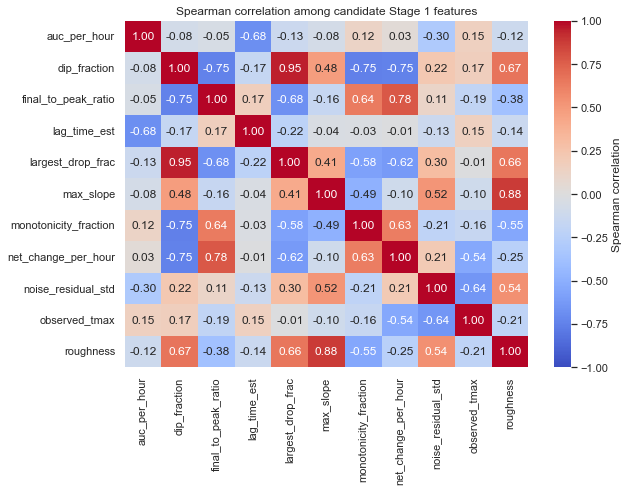

max_slope vs roughness:            r = 0.882
max_slope vs noise_residual_std:    r = 0.52
roughness vs noise_residual_std:    r = 0.539


In [6]:
corr_cols = sorted(set(CANDIDATE_10) | {"noise_residual_std", "auc_per_hour", "dip_fraction"})
corr = X[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Spearman correlation among candidate Stage 1 features")
plt.tight_layout()
plt.show()

print("max_slope vs roughness:            r =", round(corr.loc["max_slope", "roughness"], 3))
print("max_slope vs noise_residual_std:    r =", round(corr.loc["max_slope", "noise_residual_std"], 3))
print("roughness vs noise_residual_std:    r =", round(corr.loc["roughness", "noise_residual_std"], 3))

## 6. Model training across feature sets

Each of LR, RF and HGB (the same `build_models()` pipelines used in production training, with
median imputation and `class_weight="balanced"` / `balanced_subsample`) is trained on each of the
three feature sets, on the same group-aware split.

In [7]:
all_results = []
fitted_by_set = {}

for set_name, feats in {"FULL": FULL, "CANDIDATE_10": CANDIDATE_10, "FINAL_8": FINAL_8}.items():
    Xs = X[feats]
    models = build_models()
    res, fitted = fit_and_eval(models, Xs, y, eval_df, train_idx, val_idx, test_idx)
    res["feature_set"] = set_name
    all_results.append(res)
    fitted_by_set[set_name] = fitted

results = pd.concat(all_results, ignore_index=True)
print("Trained %d model/feature-set combinations." % (len(fitted_by_set) * 3))

Trained 9 model/feature-set combinations.


## 7. Performance summary (overall, val + test)

In [8]:
overall = results[results.slice_col == "overall"].copy()
summary = overall[overall.split.isin(["val", "test"])].pivot_table(
    index=["feature_set", "model"], columns="split",
    values=["balanced_acc", "f1", "roc_auc", "pr_auc"],
)
summary = summary.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
summary = summary.round(4)
summary

split                      test                                  val          \
                   balanced_acc      f1  pr_auc roc_auc balanced_acc      f1   
feature_set  model                                                             
CANDIDATE_10 HGB         0.8289  0.8538  0.9340  0.9174       0.8315  0.8624   
             LR          0.7668  0.8017  0.8589  0.8499       0.7505  0.8241   
             RF          0.8268  0.8612  0.9433  0.9243       0.8276  0.8755   
FINAL_8      HGB         0.8324  0.8507  0.9312  0.9137       0.8075  0.8497   
             LR          0.7658  0.8029  0.8409  0.8403       0.7462  0.8244   
             RF          0.8009  0.8371  0.9349  0.9151       0.8099  0.8709   
FULL         HGB         0.8401  0.8646  0.9451  0.9270       0.8418  0.8776   
             LR          0.8123  0.8356  0.9195  0.8976       0.8039  0.8541   
             RF          0.8351  0.8711  0.9506  0.9328       0.8373  0.8880   

split                               
                    pr_auc roc_auc  
feature_set  model                  
CANDIDATE_10 HGB    0.9340  0.9159  
             LR     0.8928  0.8478  
             RF     0.9376  0.9166  
FINAL_8      HGB    0.9129  0.8907  
             LR     0.8576  0.8209  
             RF     0.9273  0.9054  
FULL         HGB    0.9488  0.9320  
             LR     0.9195  0.8998  
             RF     0.9473  0.9315

## 8. Confusion matrices (test split, FINAL_8 feature set)

FINAL_8 is the working feature set intended for the thesis, so its confusion matrices on the held-out
(curve-disjoint) test split are shown here for all three model types.

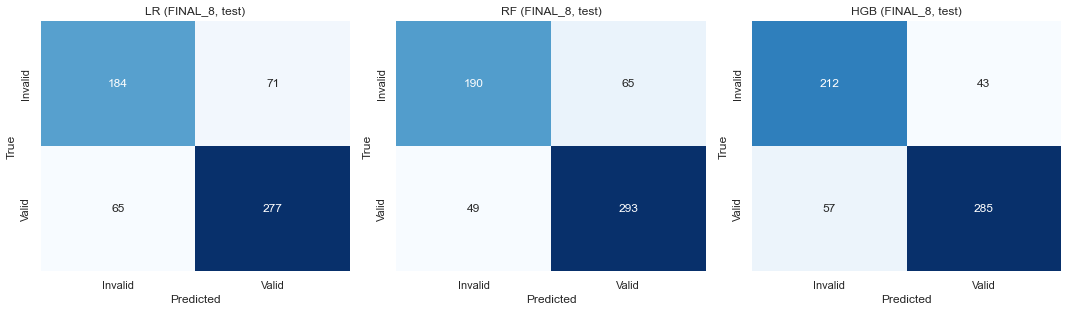

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
X_test = X[FINAL_8].iloc[test_idx]
y_test = y.iloc[test_idx]

for ax, name in zip(axes, ["LR", "RF", "HGB"]):
    model = fitted_by_set["FINAL_8"][name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Invalid", "Valid"], yticklabels=["Invalid", "Valid"])
    ax.set_title(f"{name} (FINAL_8, test)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## 9. ROC curves (test split, FINAL_8 feature set)

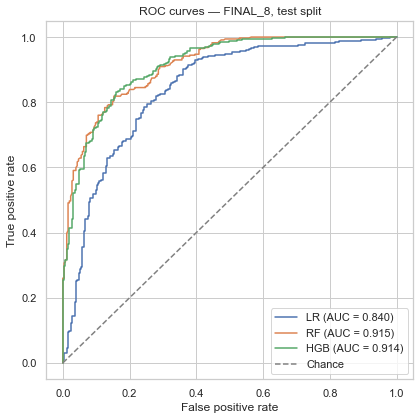

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
for name in ["LR", "RF", "HGB"]:
    model = fitted_by_set["FINAL_8"][name]
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — FINAL_8, test split")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Calibration (reliability) curves

This checks whether predicted probabilities on the test split are trustworthy as confidence scores —
directly relevant to the Unsure-threshold logic used downstream.

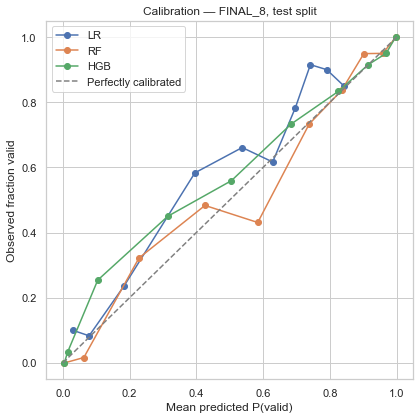

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
for name in ["LR", "RF", "HGB"]:
    model = fitted_by_set["FINAL_8"][name]
    proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted P(valid)")
ax.set_ylabel("Observed fraction valid")
ax.set_title("Calibration — FINAL_8, test split")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Feature importance and best Valid/Invalid differentiators

Four independent importance signals are computed on the FULL feature set (train split only, to avoid
using test data for feature selection): mutual information, Random Forest impurity importance,
permutation importance on HGB, and absolute LR coefficients (on standardized features). A combined
rank (lower = more important) is used to cross-check `FINAL_8` and `CANDIDATE_10` against a
data-driven ranking rather than only against each other.

In [12]:
X_train_full = X[FULL].iloc[train_idx]
y_train = y.iloc[train_idx]

lr_full = fitted_by_set["FULL"]["LR"]
rf_full = fitted_by_set["FULL"]["RF"]
hgb_full = fitted_by_set["FULL"]["HGB"]

# # Mutual information (on median-imputed values, matching what the models see)
# imputer = lr_full.named_steps["imputer"]

imputer = lr_full.named_steps["imputer"]

# SimpleImputer drops any column that is all-NaN in the data it was fit on.
# statistics_ has one entry per input feature; NaN there means the column was dropped.
valid_mask = ~np.isnan(imputer.statistics_)
kept_cols = [c for c, keep in zip(FULL, valid_mask) if keep]
dropped_cols = [c for c, keep in zip(FULL, valid_mask) if not keep]

if dropped_cols:
    print("Columns dropped by imputer (all-NaN in this fold):", dropped_cols)

X_train_imp = pd.DataFrame(
    imputer.transform(X_train_full),
    columns=kept_cols,
    index=X_train_full.index,
)

# add the dropped columns back as a constant, so the feature matrix keeps all 36 columns
for c in dropped_cols:
    X_train_imp[c] = 0.0
X_train_imp = X_train_imp[FULL]

mi = mutual_info_classif(X_train_imp, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"Feature": FULL, "Mutual Information": mi})

rf_importance = rf_full.named_steps["clf"].feature_importances_
rf_df = pd.DataFrame({"Feature": kept_cols, "RF Importance": rf_importance})

lr_coef = np.abs(lr_full.named_steps["clf"].coef_[0])
coef_df = pd.DataFrame({"Feature": kept_cols, "LR |Coefficient|": lr_coef})

perm = permutation_importance(
    hgb_full, X[FULL].iloc[val_idx], y.iloc[val_idx],
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_df = pd.DataFrame({"Feature": FULL, "HGB Permutation Importance": perm.importances_mean})

importance = (
    mi_df.merge(rf_df, on="Feature").merge(coef_df, on="Feature").merge(perm_df, on="Feature")
)
for col in ["Mutual Information", "RF Importance", "LR |Coefficient|", "HGB Permutation Importance"]:
    importance[col + " rank"] = importance[col].rank(ascending=False)

importance["Combined Rank Score"] = importance[[c for c in importance.columns if c.endswith("rank")]].sum(axis=1)
importance = importance.sort_values("Combined Rank Score").reset_index(drop=True)
importance["in_FINAL_8"] = importance["Feature"].isin(FINAL_8)
importance["in_CANDIDATE_10"] = importance["Feature"].isin(CANDIDATE_10)

importance.round(4)

Columns dropped by imputer (all-NaN in this fold): ['source_type']


,Feature,Mutual Information,RF Importance,LR |Coefficient|,HGB Permutation Importance,Mutual Information rank,RF Importance rank,LR |Coefficient| rank,HGB Permutation Importance rank,Combined Rank Score,in_FINAL_8,in_CANDIDATE_10
0,dip_fraction,0.2142,0.1060,2.2097,0.0378,1.0,2.0,1.0,2.0,6.0,False,True
1,largest_drop_frac,0.2027,0.1240,1.1332,0.1366,2.0,1.0,5.0,1.0,9.0,True,True
2,net_change_per_hour,0.1475,0.0624,1.5043,0.0093,5.0,3.0,2.0,9.0,19.0,True,True
3,roughness,0.1022,0.0584,1.2752,0.0080,10.0,4.0,3.0,11.0,28.0,True,True
4,max_slope,0.1703,0.0560,0.2910,0.0312,3.0,5.0,18.0,3.0,29.0,True,True
5,noise_residual_std,0.0370,0.0363,1.2476,0.0148,20.0,12.0,4.0,4.0,40.0,False,False
6,auc_per_hour,0.0565,0.0504,0.3901,0.0141,15.0,8.0,16.0,5.0,44.0,False,True
7,growth_phase_duration,0.0574,0.0443,0.4705,0.0130,14.0,11.0,14.0,6.0,45.0,False,False
8,initial_OD,0.1260,0.0363,0.7323,0.0037,8.0,13.0,9.0,15.0,45.0,False,False
9,auc,0.0172,0.0461,0.7587,0.0081,23.0,10.0,8.0,10.0,51.0,False,False


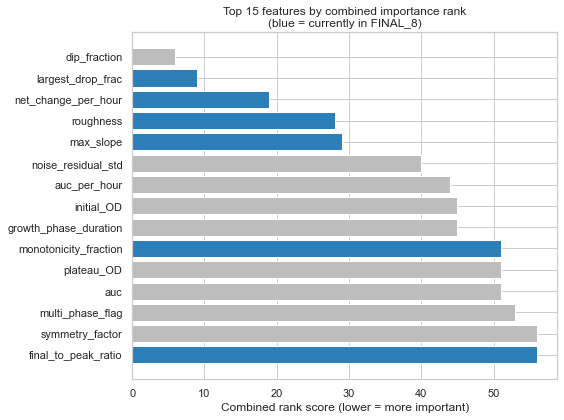

In [13]:
top15 = importance.head(15).sort_values("Combined Rank Score", ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2c7fb8" if f else "#bdbdbd" for f in top15["in_FINAL_8"]]
ax.barh(top15["Feature"], top15["Combined Rank Score"], color=colors)
ax.set_xlabel("Combined rank score (lower = more important)")
ax.set_title("Top 15 features by combined importance rank\n(blue = currently in FINAL_8)")
plt.tight_layout()
plt.show()

## 12. Ablation: FULL vs CANDIDATE_10 vs FINAL_8

The table below isolates the cost, in test-set performance, of moving from the full feature set down
to the 8-feature set actually used. Reporting this honestly — including if `FINAL_8` underperforms —
is what makes the feature-selection narrative in Chapter 5 defensible.

In [14]:
ablation = overall[overall.split == "test"].pivot_table(
    index="feature_set", columns="model", values=["balanced_acc", "f1", "roc_auc"]
).round(4)
ablation = ablation.reindex(["FULL", "CANDIDATE_10", "FINAL_8"])
ablation

balanced_acc                      f1                 roc_auc  \
model                 HGB      LR      RF     HGB      LR      RF     HGB   
feature_set                                                                 
FULL               0.8401  0.8123  0.8351  0.8646  0.8356  0.8711  0.9270   
CANDIDATE_10       0.8289  0.7668  0.8268  0.8538  0.8017  0.8612  0.9174   
FINAL_8            0.8324  0.7658  0.8009  0.8507  0.8029  0.8371  0.9137   

                              
model             LR      RF  
feature_set                   
FULL          0.8976  0.9328  
CANDIDATE_10  0.8499  0.9243  
FINAL_8       0.8403  0.9151

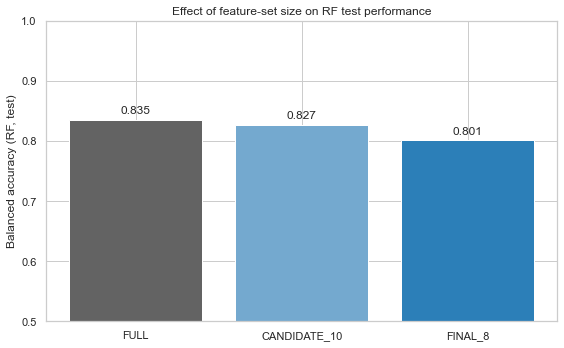

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = overall[(overall.split == "test") & (overall.model == "RF")].set_index("feature_set")
plot_df = plot_df.reindex(["FULL", "CANDIDATE_10", "FINAL_8"])
ax.bar(plot_df.index, plot_df["balanced_acc"], color=["#636363", "#74a9cf", "#2c7fb8"])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Balanced accuracy (RF, test)")
ax.set_title("Effect of feature-set size on RF test performance")
for i, v in enumerate(plot_df["balanced_acc"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

## 13. Ensemble reproduction & Unsure confidence threshold

Production inference (`infer_labels.py`, `model_name="Average"`) combines the three FINAL_8 models
with certainty-based weighting. Each model's weight is its mean certainty, |P(valid) - 0.5| averaged
over every curve in the current batch, so the weight is fixed across curves within one inference
call but shifts if the batch composition changes. This is a documented limitation of the production
ensemble: the same curve can receive a different probability depending on which curves accompany it.
That exact weighting scheme is reproduced here on the validation split and used to sweep the Unsure
confidence threshold. Three values have appeared in the codebase at different times (0.60, 0.70, 0.80);
this sweep is the evidence for picking one as canonical for the thesis.

In [16]:
def certainty_weighted_ensemble(models_dict, X_df):
    probs = []
    for name in ["LR", "RF", "HGB"]:
        p = models_dict[name].predict_proba(X_df)[:, 1]
        probs.append(p)
    probs = np.vstack(probs)  # (3, n)

    # Reproduces the exact weighting in infer_labels.py: each model's weight
    # is its mean certainty |p - 0.5| averaged over every curve in this
    # batch, not computed separately for each curve. The weight is therefore
    # constant across all curves in one call and changes only if the batch
    # composition changes. This is the batch-dependent ensemble limitation
    # documented in infer_labels.py, reproduced here rather than replaced
    # with a per-curve variant.
    eps = 1e-9
    p_clipped = np.clip(probs, eps, 1 - eps)
    model_certainty = np.nanmean(np.abs(p_clipped - 0.5), axis=1)
    if model_certainty.sum() > 0:
        model_weights = model_certainty / model_certainty.sum()
    else:
        model_weights = np.ones(len(probs)) / len(probs)

    avg_valid = np.nansum(probs * model_weights[:, np.newaxis], axis=0)
    return avg_valid

X_val_f8 = X[FINAL_8].iloc[val_idx]
y_val = y.iloc[val_idx]
p_valid_val = certainty_weighted_ensemble(fitted_by_set["FINAL_8"], X_val_f8)

rows = []
for th in [0.60, 0.70, 0.80]:
    valid_th, invalid_th = th, 1 - th
    label = np.where(p_valid_val >= valid_th, "Valid",
             np.where(p_valid_val <= invalid_th, "Invalid", "Unsure"))
    decided = label != "Unsure"
    coverage = decided.mean()
    if decided.sum() > 0:
        pred_bin = (label[decided] == "Valid").astype(int)
        acc_on_decided = (pred_bin == y_val.values[decided]).mean()
    else:
        acc_on_decided = np.nan
    rows.append({
        "threshold": th,
        "coverage (fraction decided)": round(coverage, 4),
        "accuracy on decided curves": round(acc_on_decided, 4),
        "n_unsure": int((~decided).sum()),
    })

threshold_sweep = pd.DataFrame(rows)
threshold_sweep

,threshold,coverage (fraction decided),accuracy on decided curves,n_unsure
0,0.6,0.8576,0.8613,85
1,0.7,0.7169,0.9182,169
2,0.8,0.5276,0.9492,282


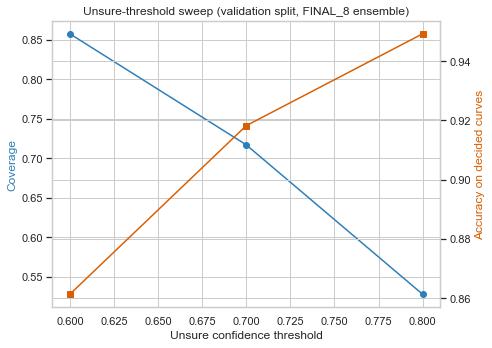

In [17]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()
ax1.plot(threshold_sweep["threshold"], threshold_sweep["coverage (fraction decided)"],
         marker="o", color="#2c7fb8", label="Coverage")
ax2.plot(threshold_sweep["threshold"], threshold_sweep["accuracy on decided curves"],
         marker="s", color="#d95f02", label="Accuracy on decided curves")
ax1.set_xlabel("Unsure confidence threshold")
ax1.set_ylabel("Coverage", color="#2c7fb8")
ax2.set_ylabel("Accuracy on decided curves", color="#d95f02")
ax1.set_title("Unsure-threshold sweep (validation split, FINAL_8 ensemble)")
plt.tight_layout()
plt.show()

## 14. Failure case analysis by curve subtype

`Curve Subtype` (plain / fast / late / decline for valid curves; obvious / subtle /
nearreal / decline_only / diauxic / noise / nogrowth for invalid ones) is only
present in the raw synthetic wide file - it is intentionally not carried through the meta-feature
pipeline into `meta.csv` (see Section 1's keep-list), so it is re-attached here purely for
diagnostics, via `Test Id`.

In [18]:
import pandas as pd
wide_synth = pd.read_csv("../data/pipeline_data/timeseries_wide_SD1.csv")
subtype_map = wide_synth.set_index("Test Id")["Curve Subtype"]

X_test_full = X[FULL].iloc[test_idx]
test_meta = meta.iloc[test_idx].copy()
test_meta["Curve Subtype"] = test_meta["Test Id"].map(subtype_map).fillna("lab (no subtype)")

rf_f8 = fitted_by_set["FINAL_8"]["RF"]
test_meta["pred"] = rf_f8.predict(X[FINAL_8].iloc[test_idx])
test_meta["correct"] = (test_meta["pred"] == test_meta["Is_Valid"]).astype(int)

failure_by_subtype = (
    test_meta.groupby("Curve Subtype")
    .agg(n=("correct", "size"), accuracy=("correct", "mean"))
    .sort_values("accuracy")
)
failure_by_subtype

,n,accuracy
Curve Subtype,,
diauxic,27,0.518519
subtle,39,0.564103
nearreal,30,0.633333
obvious,42,0.666667
late,42,0.714286
decline,81,0.740741
nogrowth,33,0.848485
plain,105,0.876190
noise,45,0.888889


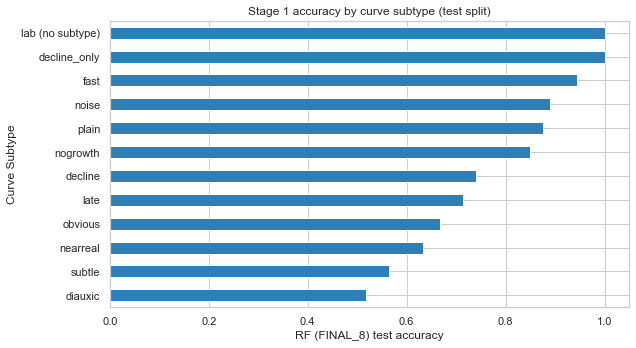

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
failure_by_subtype["accuracy"].plot(kind="barh", ax=ax, color="#2c7fb8")
ax.set_xlabel("RF (FINAL_8) test accuracy")
ax.set_xlim(0, 1.05)
ax.set_title("Stage 1 accuracy by curve subtype (test split)")
plt.tight_layout()
plt.show()

## 15. Saving Stage 1 artifacts (FINAL_8)

This reuses the production `train_from_meta_csv()` function directly (rather than re-implementing
saving logic here) so the artifacts produced are identical in structure to what the CLI/app would
produce, keeping code and thesis in sync.

In [20]:
ART_DIR = Path("classifier_output_notebook_run")
train_out = train_from_meta_csv(
    meta_csv=META_CSV,
    art_dir=ART_DIR,
    run_tag="v03_final8",
    write_lockfile=False,
    selected_features=FINAL_8,
)
print(json.dumps({k: v for k, v in train_out.items() if k not in ("feature_columns",)}, indent=2))

{
  "run_tag": "v03_final8",
  "meta_csv": "..\\data\\train_data\\training_meta.csv",
  "label_col": "Is_Valid",
  "feature_count": 8,
  "group_split_col": "base_curve_id",
  "model_paths": {
    "LR": "classifier_output_notebook_run\\LR_selected_pipeline_v03_final8.joblib",
    "RF": "classifier_output_notebook_run\\RF_selected_pipeline_v03_final8.joblib",
    "HGB": "classifier_output_notebook_run\\HGB_selected_pipeline_v03_final8.joblib"
  },
  "manifest_paths": {
    "LR": "classifier_output_notebook_run\\LR_selected_pipeline_v03_final8.manifest.json",
    "RF": "classifier_output_notebook_run\\RF_selected_pipeline_v03_final8.manifest.json",
    "HGB": "classifier_output_notebook_run\\HGB_selected_pipeline_v03_final8.manifest.json"
  },
  "selected_features_path": "classifier_output_notebook_run\\selected_features_v03_final8.json",
  "thresholds_path": "classifier_output_notebook_run\\thresholds_v03_final8.json",
  "results_path": "classifier_output_notebook_run\\train_results_sele

## 16. Inference demonstration — Stage 1 (≤16 h) + Stage 2 (>16 h evidence)

Two demo files are used, one generated by the same `growthqa synth` generator used to build the
training data (so they are methodologically consistent with it, not hand-crafted):

- **`lab_16h_0.25_Sparse_Extr.csv`** — the real 7-curve lab file (`lab_16h_0.25.csv`).
- **`test_curves_tmax20h.csv`** — a 8-curve synthetic set generated out to 20 h, so Stage
  1 sees only the first 16 h (as it always does) while Stage 2 has a genuine 16–20 h late window to
  check against.

In [21]:
import sys
sys.path.insert(0, "src")
from growthqa.pipelines.infer_labels import run_label_inference_from_uploaded_wide

class Settings:
    input_is_raw = False
    step = 0.25
    min_points = 3
    low_res_threshold = 7
    tmax_hours = 16.0
    auto_tmax = False
    auto_tmax_coverage = 0.8
    clip_negatives = False
    global_blank = None
    smooth_method = "SGF"
    smooth_window = 5
    normalize = "MINMAX"

MODEL_DIR = str(ART_DIR)

demo_lab = pd.read_csv("../data/test_data/lab/lab_16h_0.25_Sparse_Extr.csv")
demo_beyond16h = pd.read_csv("../data/test_data/synthetic/test_curves_tmax20h.csv")

for demo_df, tag in [(demo_lab, "lab_16h_0.25_Sparse_Extr"), (demo_beyond16h, "test_curves_tmax20h")]:
    if "FileName" not in demo_df.columns:
        demo_df["FileName"] = tag
    if "Model Name" not in demo_df.columns:
        demo_df["Model Name"] = "Uploaded"
    if "Is_Valid" not in demo_df.columns:
        demo_df["Is_Valid"] = True

out_lab = run_label_inference_from_uploaded_wide(
    wide_df=demo_lab, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)
out_b16 = run_label_inference_from_uploaded_wide(
    wide_df=demo_beyond16h, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)

print("=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===")
print(out_lab["out_df"]["Stage 2 Label"].value_counts())
print(out_lab["out_df"]["final_label"].value_counts())
print()
print("=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===")
print(out_b16["out_df"]["Stage 2 Label"].value_counts())
print(out_b16["out_df"]["final_label"].value_counts())

=== lab_16h_0.25_Sparse_Extr.csv (7 lab curves, <= 16h) ===
Insufficient    7
Name: Stage 2 Label, dtype: int64
Valid    7
Name: final_label, dtype: int64

=== test_curves_tmax20h.csv (8 synthetic curves, extend to 20h) ===
Corroborated     7
Contradiction    1
Name: Stage 2 Label, dtype: int64
Valid      5
Invalid    2
Unsure     1
Name: final_label, dtype: int64


In [22]:
cols = ["Test Id", "Pred Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("Sample of the >16h demo predictions (Stage 2 evidence engaged):")
out_b16["out_df"][cols].head(12)

Sample of the >16h demo predictions (Stage 2 evidence engaged):


,Test Id,Pred Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,L01,Valid,0.9470,Corroborated,S2_STABLE_OR_PLATEAU,Valid
1,L02,Valid,0.9642,Corroborated,S2_STABLE_OR_PLATEAU,Valid
2,L03,Invalid,0.0294,Corroborated,S2_CORROBORATES_INVALID,Invalid
3,L04,Invalid,0.0911,Corroborated,S2_CORROBORATES_INVALID,Invalid
4,L05,Valid,0.9571,Contradiction,S2_LATE_DECLINE_DETECTED: Confidence(Valid) = ...,Unsure
5,L06,Valid,0.9587,Corroborated,S2_STABLE_OR_PLATEAU,Valid
6,L07,Valid,0.9551,Corroborated,S2_STABLE_OR_PLATEAU,Valid
7,L08,Valid,0.7955,Corroborated,S2_STABLE_OR_PLATEAU,Valid


## 17. Summary for Chapter 5

Points this notebook gives direct evidence for:

- The `source_type` mislabelling bug (Section 1) and its fix — worth a short reproducibility note.
- `FINAL_8` vs `CANDIDATE_10` vs `FULL` performance (Sections 7, 12) — quantifies the cost of the
  8-feature reduction rather than asserting it.
- Feature importance ranking (Section 11) — supports or challenges the specific choice of features
  in `FINAL_8` against a data-driven combined rank.
- Collinearity between `max_slope` and `roughness`, and where `noise_residual_std` sits relative to
  both (Section 5).
- Calibration quality of predicted probabilities (Section 10) — relevant to whether the Unsure
  threshold logic is well-founded.
- Coverage/accuracy trade-off across the three historical threshold values (Section 13) — evidence
  for picking one canonical threshold.
- Per-subtype accuracy (Section 14) — identifies which failure modes (e.g. `diauxic`, `nearreal`)
  are hardest for Stage 1, useful for the limitations discussion.
- A worked Stage 1 + Stage 2 inference example (Section 16), with an explicit caveat that a true
  >16 h *lab* example is still needed.

**Open item:** none of this resolves what exactly was in the missing
`Stage1_Feature_Exploration_Selection_Training_v2.ipynb`. This notebook is offered as its
replacement/reconstruction going forward — if you still have any exported output from the original
(a printed feature ranking, a saved metrics table, even a screenshot), it would be worth cross-checking
against Section 11 above.